In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import re
from pathlib import Path
import string
import pickle

from functools import partial

In [3]:
from imblearn.pipeline import Pipeline # supports for oversampling step
# from sklearn.pipeline import Pipeline
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import (
    StratifiedKFold,
    KFold,
    GridSearchCV,
    RandomizedSearchCV,
    cross_val_score,
    train_test_split)
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    ConfusionMatrixDisplay,
    roc_curve, 
    roc_auc_score,
    f1_score)

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression  # TODO we can also use this
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.decomposition import TruncatedSVD

from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [25]:
from rital.data import (
    load_presidents,
    load_presidents_unseen,
)
from rital.preprocessing import (
    compute_odds_ratio,
    plot_frequencies,
    plot_word_cloud
)

from rital.presidents.preprocessing import (
    preprocess,
    tokenizer
)

from rital.presidents.analysis import (
    plot_roc_pr,
    ordered_train_test_split,
    plot_train_test_cm,
    TextStats
)

from rital.presidents.postprocessing import (
    smooth,
    plot_smoothing,
    calibrate_proba,
    adjust_threshold,
    adjust_proba,
    SmoothLogisticRegression,
    SmoothSVM,
    SmoothMultinomialNB,
    SmoothRandomForest,
    SmoothXGBoost
)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
from nltk.stem import SnowballStemmer
from nltk.corpus import stopwords

## Data Loading

In [61]:
X_train_full, y_train_full = load_presidents()
X_test_unseen = load_presidents_unseen()
label2name = {
    0 : "Chirac",
    1 : "Mitterrand"
}
X_train_full_embeddings = np.load("X_train_full_embeddings.npy")
STEMMER = SnowballStemmer("french")
STOP_WORDS = stopwords.words("french")

## Train-test split preserving order

In [62]:
FIT_ON_UNSEEN = False
if FIT_ON_UNSEEN:
    X_train = X_train_full
    y_train = y_train_full
    X_test = X_test_unseen
    y_test = None # Unseen
    
    X_test_embeddings = None  # X_test_unseen_embeddings # Not done yet
    X_train_embeddings = X_train_full_embeddings

else:    
    X_train, X_train_embeddings, y_train, X_test, X_test_embeddings, y_test = ordered_train_test_split(
        X_train_full, y_train_full, X_train_full_embeddings,
        test_size=0.2, random_state=2, 
        shuffle = False,
        stratify=False
        )
    print(f"Original imbalance: { (y_train_full == 0).sum() / (y_train_full == 1).sum() :.2f}")
    print(f"Train imbalance: {(y_train == 0).sum() / (y_train == 1).sum() :.2f}")
    print(f"Test imbalance: {(y_test == 0).sum() / (y_test == 1).sum() :.2f}")
    # NOTE: test set is less balanced, so performance is underestimated

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', 
                                    classes=classes, 
                                    y=y_train)
class_weight_dict = {cls: w for cls, w in zip(classes, class_weights)}
sample_weights = np.array([class_weight_dict[y] for y in y_train])

Original imbalance: 6.63
Train imbalance: 6.22
Test imbalance: 8.87


In [82]:

# POS_WEIGHT = 0.7
base_model = Pipeline(
    [
        ("features", 
         
            # FeatureUnion([
            # ("word_ngrams",
             
             TfidfVectorizer(
                # analyzer="word",
                # preprocessor = partial(preprocess, stemmer = None),
                # tokenizer = tokenizer,
                # token_pattern = None,
                ngram_range=(1, 2),
                stop_words=STOP_WORDS,
                max_features=50_000,
                sublinear_tf = True,
                min_df=1,
                max_df=1.0
                
            )
            #  ), # type: ignore
            
            # ("char_ngrams", TfidfVectorizer(
            #     analyzer="char",
            #     ngram_range=(3, 6), # (2,5)
            #     max_features=50_000,
            #     lowercase=True,#False,
            #     sublinear_tf = True,
            #     min_df=2,
            #     max_df=0.9,
            # )), # type: ignore
            # ("text_stats", Pipeline([
            #     ("stats", TextStats()),
            #     ("scaler", StandardScaler())
            # ])) # type: ignore
            # ]) 
         
        ),
        # ("rus", RandomUnderSampler(sampling_strategy=0.3)),
        # ("ros", RandomOverSampler(sampling_strategy=1)),
        # ("svd", TruncatedSVD(n_components=300)),
        # ("scaler", StandardScaler()),
        ("classifier", 
            # CalibratedClassifierCV(
            # LinearSVC(C=5, class_weight="balanced"), # TODO: tune C, class balance?
            # method="sigmoid",
            # cv=5
            # )
            
            SmoothLogisticRegression(
                l1_ratio=0, 
                # solver="saga", 
                class_weight='balanced',#{0:1-POS_WEIGHT, 1:POS_WEIGHT},#'balanced', 
                C=5,
                max_iter=2000,
                smooth_size=21,
                pred_threshold=0.4
                )
            
            # SmoothMultinomialNB(fit_prior=False),
            
            # SmoothSVM(kernel="linear", class_weight="balanced", smooth_size=17,pred_threshold=0.45)
            # SmoothRandomForest(class_weight="balanced")
            # SmoothXGBoost(scale_pos_weight=(y_train_full == 0).sum() / (y_train_full == 1).sum())
         ),
    ]
)
assert hasattr(base_model, "predict_proba"), "They require to submit probabilities"

In [83]:
TUNE = False
if TUNE:
    kf = KFold(n_splits=5, shuffle=False) # Preserve order
    
    param_grid = {
        # Word-level TF-IDF
        "features__word_ngrams__ngram_range": [(1, 1), (1, 2), (1, 3)],
        "features__word_ngrams__sublinear_tf": [True, False],
        # You can also test stop words inclusion
        # "features__word_ngrams__stop_words": [None, "english"],
        "features__word_ngrams__max_df": [0.9, 1.0],
        "features__word_ngrams__min_df": [1, 3],
        
        # Character-level TF-IDF
        # "features__char_ngrams__ngram_range": [(2, 4), (2, 5), (3, 6)],
        # "features__char_ngrams__sublinear_tf": [True, False],
        # "features__char_ngrams__lowercase": [True, False],

        # SmoothLogisticRegression
        "classifier__C": [0.1, 1, 5, 10],
        # "classifier__l1_ratio": [0],#[0, 0.5, 1],  # Only used with 'saga' solver
        # "classifier__class_weight": ["balanced", None],
        # "classifier__max_iter": [500, 1000, 2000],
    
        "classifier__smooth_size": [15, 17, 19, 21, 23],
        "classifier__pred_threshold": [0.35,0.4, 0.45, 0.5,],
    }
    grid = RandomizedSearchCV( # or GridSearchCV overnight...
        estimator=base_model,
        param_distributions=param_grid,
        n_iter=100, # ~ 2 iter/min
        scoring="f1",# or "average_precision"
        cv=kf,
        n_jobs=-1,
        verbose=3)
    grid.fit(X_train, y_train)
else:
    base_model.fit(X_train, 
          y_train, 
          )
    grid = None

In [84]:
if TUNE:
    print("Best params:", grid.best_params_)
    print("Best CV F1:", grid.best_score_)
    model = grid.best_estimator_
    #  {'features__word_ngrams__sublinear_tf': False, 'features__word_ngrams__ngram_range': (1, 3), 'features__word_ngrams__min_df': 1, 'features__word_ngrams__max_df': 0.8, 'features__char_ngrams__sublinear_tf': False, 'features__char_ngrams__ngram_range': (3, 6), 'features__char_ngrams__lowercase': True, 'classifier__smooth_size': 17, 'classifier__pred_threshold': 0.4, 'classifier__max_iter': 2000, 'classifier__l1_ratio': 0, 'classifier__class_weight': 'balanced', 'classifier__C': 5}
else:
    model = base_model

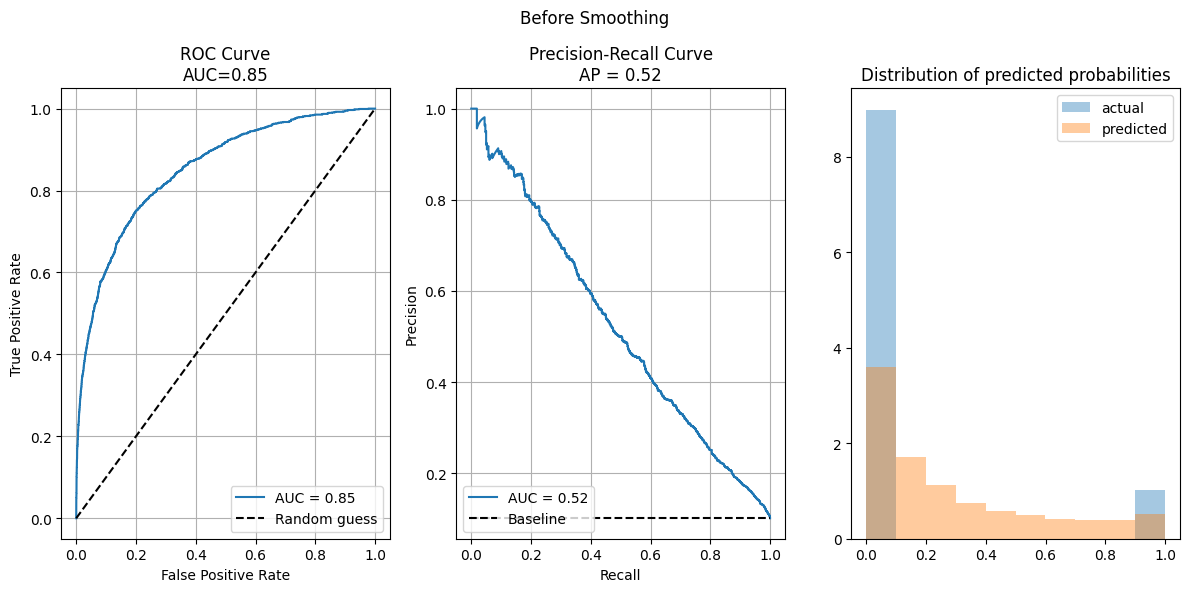

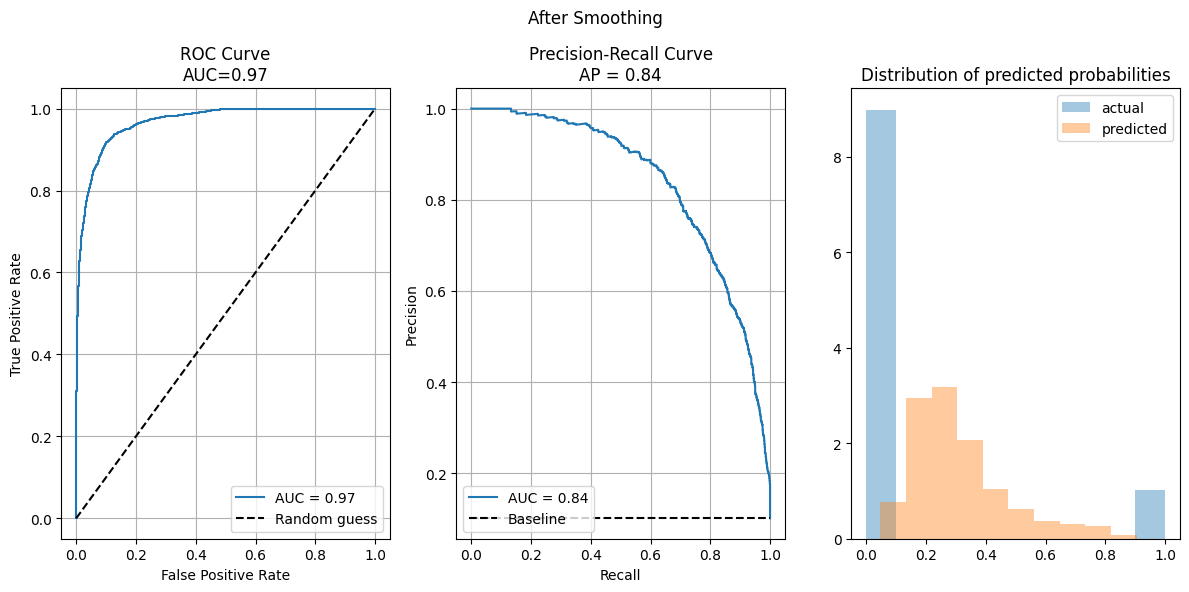

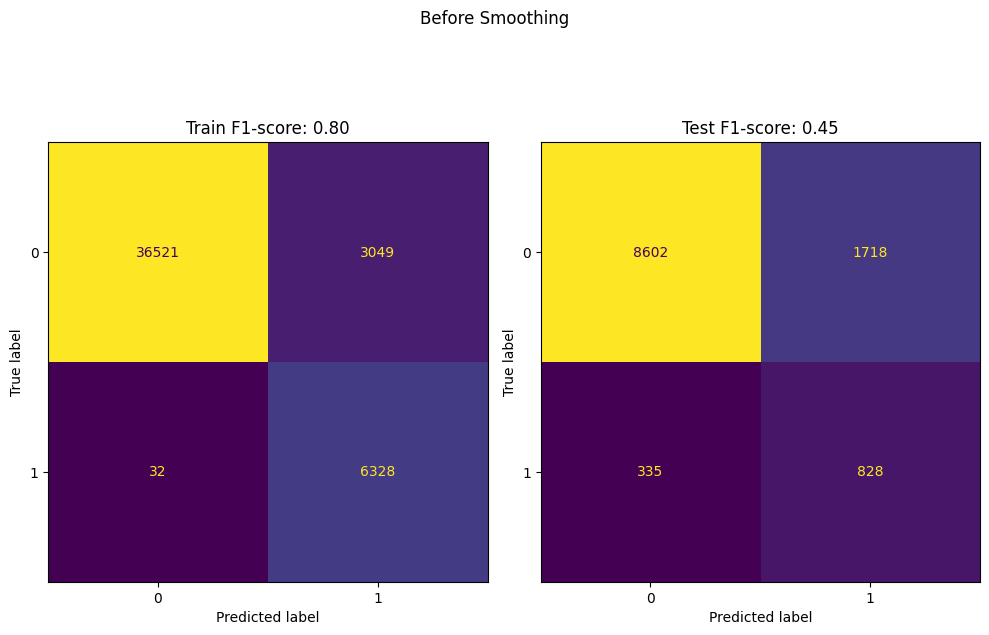

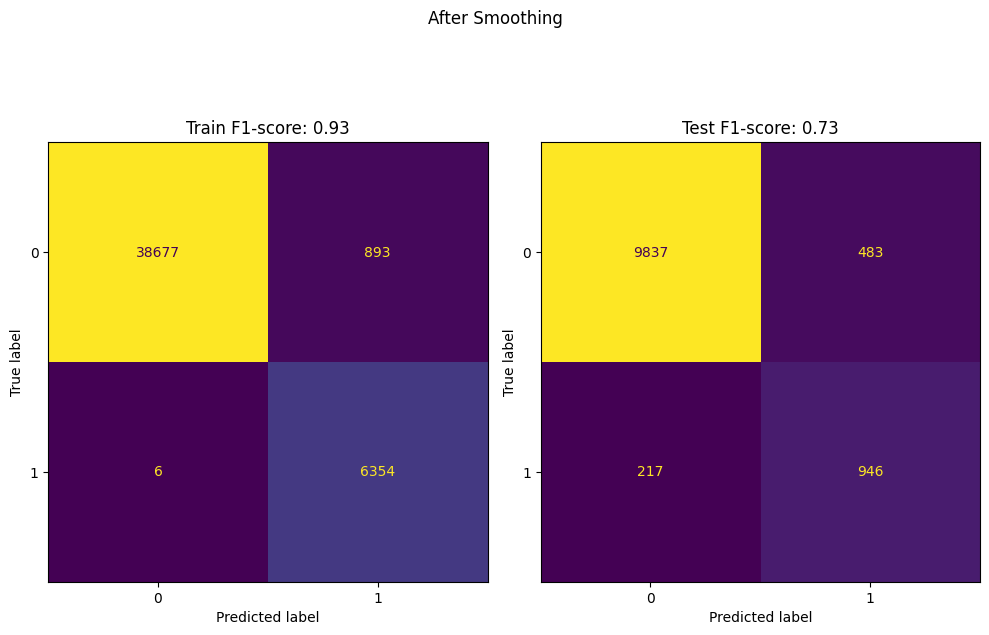

In [85]:

# smooth_size / pred_threshold= None Keeps the one that was defined before learning or after tuning
# smooth_size = 0 / pred_threshold = 0.5 applies no smoothing / adjustment of threshold
y_proba_train = model.predict_proba(X_train, 
                                    smooth_size=0
                                    )[:, 1]
y_proba_train_smoothed = model.predict_proba(X_train, 
                                             smooth_size=None,
                                             pred_threshold=None
                                             )[:, 1]
y_proba = model.predict_proba(X_test, 
                              smooth_size=0
                              )[:, 1]
y_proba_smoothed = model.predict_proba(X_test, 
                                       smooth_size=None,
                                       pred_threshold=None
                                       )[:, 1] 

if not FIT_ON_UNSEEN:
    plot_roc_pr(y_test, y_proba, title="Before Smoothing")
    plt.savefig("../plots/pres-curves_before_smoothing_logreg.pdf")
    plt.show()
    plot_roc_pr(y_test, y_proba_smoothed, title="After Smoothing")
    plt.savefig("../plots/pres-curves_after_smoothing_logreg.pdf")
    plt.show()
    plot_train_test_cm(y_train, y_test, y_proba_train, y_proba, title="Before Smoothing")
    plot_train_test_cm(y_train, y_test, y_proba_train_smoothed, y_proba_smoothed, title="After Smoothing")

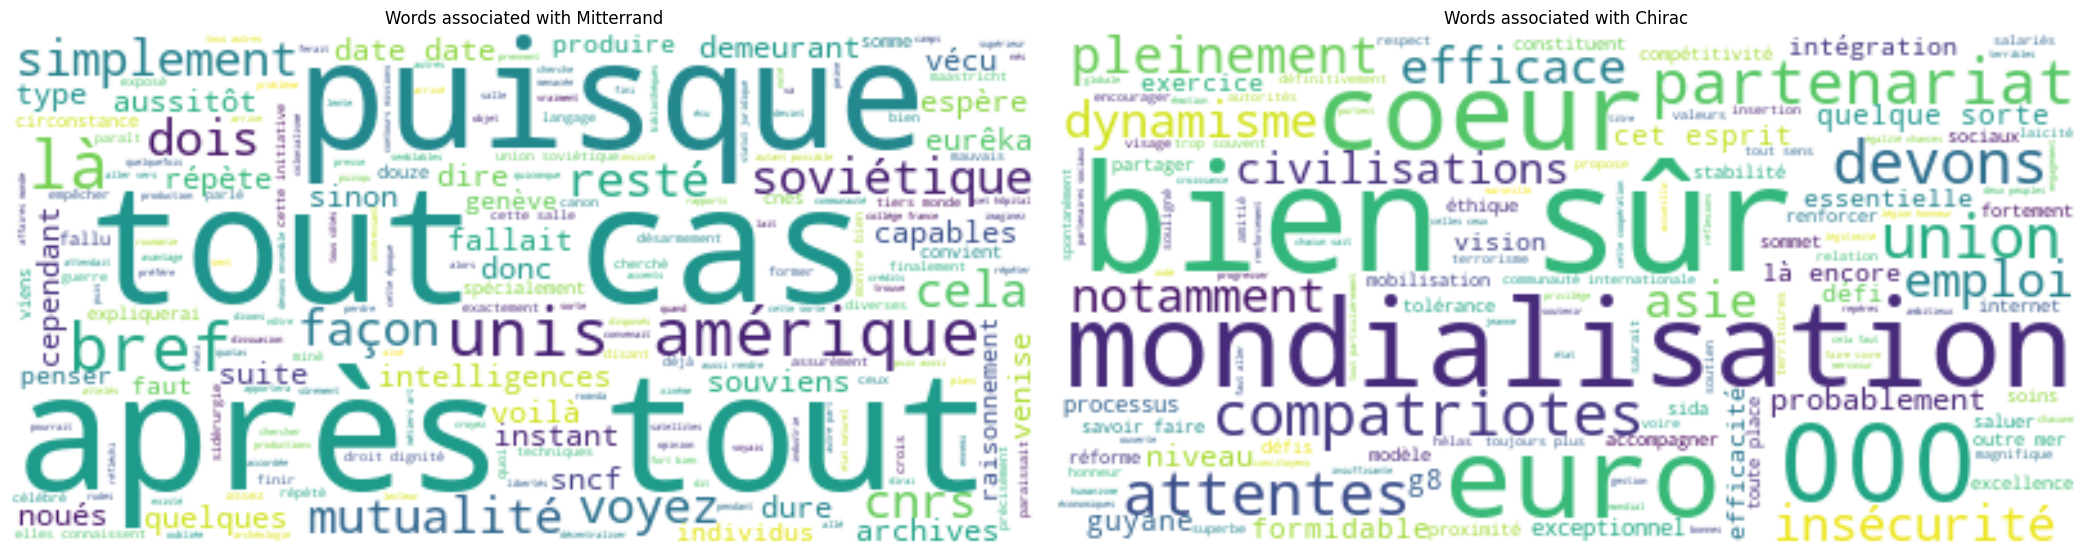

In [92]:
if hasattr(model.named_steps["classifier"], "coef_") and "svd" not in model.named_steps:
    feature_names = model.named_steps["features"].get_feature_names_out()
    feature_coef = model.named_steps["classifier"].coef_.reshape(-1)
    fig, axes = plt.subplots(1,2, figsize=(21,7))
    plot_word_cloud(feature_names, feature_coef,
                    title=f"Words associated with {label2name[1]}", ax=axes[0])
    # plot_frequencies(feature_names, feature_coef, top_k=25, title=f"Words associated with {label2name[1]}")
    plot_word_cloud(feature_names, -feature_coef, 
                    title=f"Words associated with {label2name[0]}", ax=axes[1])
    plt.tight_layout()
    plt.savefig("../plots/pres-logreg_coefs.pdf")
    plt.show()
    # plot_frequencies(feature_names, -feature_coef, top_k=25, title=f"Words associated with {label2name[0]}")

# Visualize Smoothing

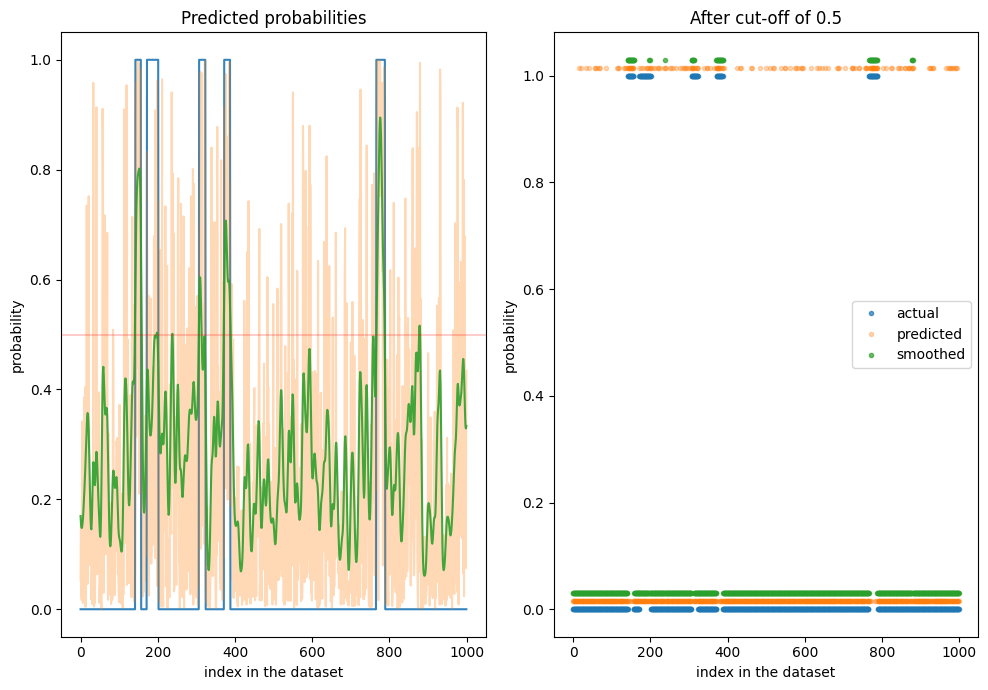

In [48]:
plot_smoothing(y_test, y_proba, y_proba_smoothed,slc=slice(1000, 2000))
plt.savefig("../plots/pres-smoothing_logreg.pdf")

In [14]:
if FIT_ON_UNSEEN:
    with open("submission-pres-TEST.csv","w") as file:
        for p in y_proba_smoothed:
            file.write(str(p)+"\n")

# SANDBOX

## Nested Cross Validation

In [15]:
TUNE = False
if TUNE:
    # Outer CV (evaluation)
    outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Inner CV (tuning)
    inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Pipeline
    model = Pipeline(
        [
            ("tfidf", TfidfVectorizer(preprocessor=preprocess)),
            ("classifier", LinearSVC()),
        ]
    )

    # Grid
    param_grid = {
        "tfidf__ngram_range": [(1, 1), (1, 2)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_df": [0.9, 1.0],
        "tfidf__sublinear_tf": [False, True],
        "classifier__C": [0.01, 0.1, 1, 10],
        "classifier__class_weight": ["balanced"],
    }

    # Inner loop: GridSearch
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=inner_cv,
        scoring="f1",
        n_jobs=-1,
    )

    # Outer loop: evaluation
    nested_scores = cross_val_score(
        grid,                # <- important: NOT best_model
        X_train_full,
        y_train_full,
        cv=outer_cv,
        scoring="f1",
        n_jobs=-1,
    )

    print("Nested CV F1 score:")
    print(f"Mean: {nested_scores.mean():.4f}")
    print(f"Std: {nested_scores.std():.4f}")

    # Refit on FULL training data
    final_grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=inner_cv,       
        scoring="f1",
        n_jobs=-1,
    )

    final_grid.fit(X_train_full, y_train_full)

    final_model = final_grid.best_estimator_

    print("Final best parameters:", final_grid.best_params_)

# SKELETONS

In [16]:
# model = Pipeline(
#     [
#         ("features", 
         
#             FeatureUnion([
#             ("word_ngrams",
#             TfidfVectorizer(
#                 analyzer="word",
#                 preprocessor = partial(preprocess, stemmer = None),
#                 tokenizer = tokenizer,
#                 token_pattern = None,
#                 ngram_range=(1, 2),
#                 stop_words=STOP_WORDS,
#                 max_features=50_000,
#                 sublinear_tf = True,
#                 min_df=2,
#                 max_df=0.9
                
#             )), # type: ignore
            
#             ("char_ngrams", TfidfVectorizer(
#                 analyzer="char",
#                 ngram_range=(2, 5),
#                 max_features=50_000,
#                 lowercase=False,
#                 sublinear_tf = True,
#                 min_df=2,
#                 max_df=0.9,
#             )), # type: ignore
#             ("text_stats", Pipeline([
#                 ("stats", TextStats()),
#                 ("scaler", StandardScaler())
#             ])) # type: ignore
#             ]) 
         
#         ),
#         # ("ros", RandomOverSampler(sampling_strategy=1)),
#         # ("svd", TruncatedSVD(n_components=300)),
#         # ("scaler", StandardScaler()),
#         ("classifier", 
#             # CalibratedClassifierCV(
#             # LinearSVC(C=1), # TODO: tune C, class balance?
#             # method="sigmoid",
#             # cv=3
#             # )
#         # LinearSVC(C=0.1,class_weight="balanced")
#         # XGBClassifier(),
#         LogisticRegression(
#             l1_ratio=0, 
#             # solver="saga", 
#             class_weight='balanced', 
#             C=1,
#             max_iter=1000)
#         # MultinomialNB(fit_prior=False) # balance classes by uniform prior?
        
#          ),
#     ]
# )
# assert hasattr(model, "predict_proba"), "They require to submit probabilities"
# model.fit(X_train, y_train,
#   classifier__sample_weight=sample_weights, # for XGBClassifier
# )

In [17]:
# ALPHA_CALIBRATE_PROBA = 0 # How stongly prior influences the correction 
#                           # 0 - no calibration, 1 - full calibration
# ADJUST_PROBA = False # so that optimal threshold for F1 score is 0.5
# if ALPHA_CALIBRATE_PROBA > 0:
#     y_proba, y_proba_train = calibrate_proba(y_proba, y_proba_train, y_train, alpha=ALPHA_CALIBRATE_PROBA)
# if ADJUST_PROBA:
#     best_threshold = adjust_threshold(model, X_train, y_train)
#     print(f"Cross-validated threshold to increase F1-score: {best_threshold}")
#     y_proba = adjust_proba(y_proba, best_threshold)
#     y_proba_train = adjust_proba(y_proba_train, best_threshold)

In [18]:
# # ADJUST_THRESHOLD = False
# # if ADJUST_THRESHOLD:
# #     best_threshold = adjust_threshold(model, X_train, y_train, smooth_size=SMOOTH_SIZE)
# #     print(f"Cross-validated threshold to increase F1-score: {best_threshold}")
# # else:
# best_threshold = 0.5 # BY DEFAULT 0.5, but can play around manually
    
# if best_threshold != 0.5:
#     y_proba_smoothed_adjusted = adjust_proba(y_proba_smoothed, best_threshold)
# else:
#     y_proba_smoothed_adjusted = y_proba_smoothed